Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using zips:
  Encroached  : /content/drive/MyDrive/FootpathVision/Encroached.zip
  Unencroached: /content/drive/MyDrive/FootpathVision/Unencroached.zip
Extracted 719 → Encroached
Extracted 519 → Unencroached

Classes extracted: ['Unencroached', 'Encroached']
Unencroached: 415 train, 104 val
Encroached: 575 train, 144 val

Using device: cpu
Detected classes: ['Encroached', 'Unencroached']

Model loaded.

Epoch 1/5


Training:   0%|          | 0/31 [00:00<?, ?it/s]

Validating:   0%|          | 0/8 [00:00<?, ?it/s]

Train Acc=0.734 | Val Acc=0.423

Epoch 2/5


Training:   0%|          | 0/31 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/8 [00:00<?, ?it/s]

Train Acc=0.796 | Val Acc=0.835

Epoch 5/5


Training:   0%|          | 0/31 [00:00<?, ?it/s]

Validating:   0%|          | 0/8 [00:00<?, ?it/s]

Train Acc=0.812 | Val Acc=0.827


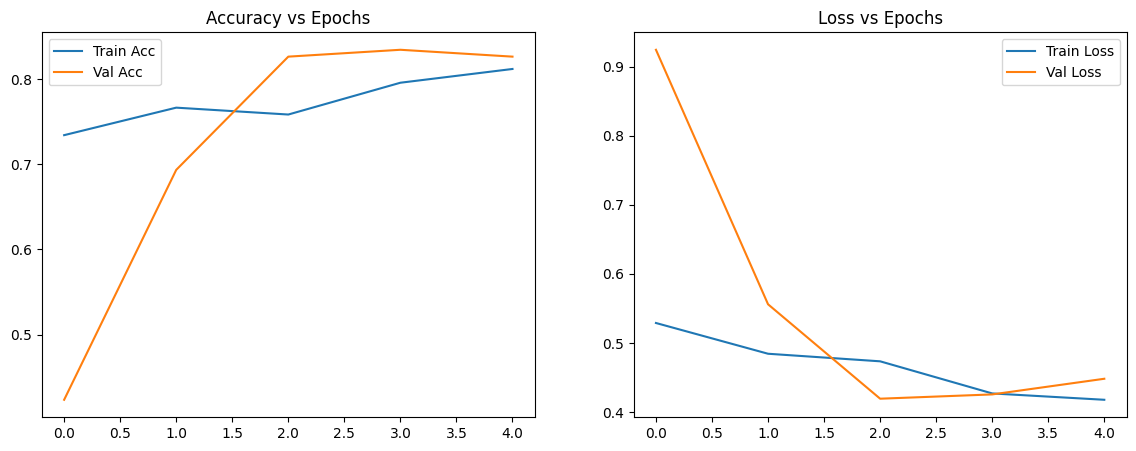

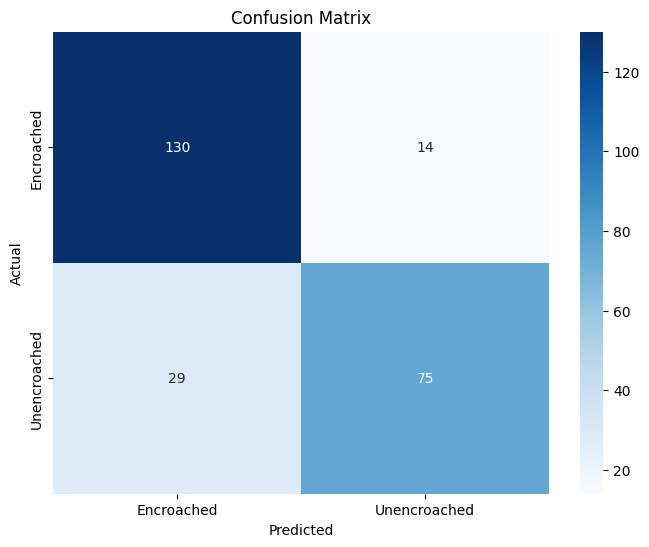

In [ ]:
import os, zipfile, shutil, random
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from PIL import Image

from google.colab import drive
drive.mount('/content/drive')

FOOT_DIR   = "/content/drive/MyDrive/FootpathVision"
ENC_ZIP    = os.path.join(FOOT_DIR, "Encroached.zip")
UNENC_ZIP  = os.path.join(FOOT_DIR, "Unencroached.zip")

print("Using zips:")
print("  Encroached  :", ENC_ZIP)
print("  Unencroached:", UNENC_ZIP)

BASE_DIR      = "/content/footpath_project"
RAW_DIR       = os.path.join(BASE_DIR, "raw")
SPLIT_ROOT    = os.path.join(BASE_DIR, "split")
TRAIN_DIR     = os.path.join(SPLIT_ROOT, "train")
VAL_DIR       = os.path.join(SPLIT_ROOT, "val")

shutil.rmtree(BASE_DIR, ignore_errors=True)

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)

def extract_zip_to_class(zip_path, class_name, raw_root):
    exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    class_dir = os.path.join(raw_root, class_name)
    os.makedirs(class_dir, exist_ok=True)

    count = 0
    with zipfile.ZipFile(zip_path, "r") as z:
        for name in z.namelist():
            if name.endswith("/") or not name.lower().endswith(exts):
                continue

            fname = os.path.basename(name)
            if fname == "":
                continue

            dest = os.path.join(class_dir, fname)
            base, ext = os.path.splitext(fname)
            i = 1
            while os.path.exists(dest):
                dest = os.path.join(class_dir, f"{base}_{i}{ext}")
                i += 1

            with z.open(name) as src, open(dest, "wb") as dst:
                shutil.copyfileobj(src, dst)

            count += 1

    print(f"Extracted {count} → {class_name}")
    return count

extract_zip_to_class(ENC_ZIP,   "Encroached",   RAW_DIR)
extract_zip_to_class(UNENC_ZIP, "Unencroached", RAW_DIR)

print("\nClasses extracted:", os.listdir(RAW_DIR))

random.seed(42)

for cls in os.listdir(RAW_DIR):
    cls_src = os.path.join(RAW_DIR, cls)
    imgs = [f for f in os.listdir(cls_src)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))]

    random.shuffle(imgs)
    split = int(0.8 * len(imgs))

    train_imgs = imgs[:split]
    val_imgs   = imgs[split:]

    os.makedirs(os.path.join(TRAIN_DIR, cls), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(cls_src, img),
                    os.path.join(TRAIN_DIR, cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(cls_src, img),
                    os.path.join(VAL_DIR, cls, img))

    print(f"{cls}: {len(train_imgs)} train, {len(val_imgs)} val")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR, val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)

class_names = train_ds.classes
num_classes = len(class_names)

print("Detected classes:", class_names)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )
    def forward(self, x):
        return self.block(x)

class DepthwiseSeparableBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, 3, stride, 1, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        return torch.relu(self.bn(self.pw(self.dw(x))))

class ResidualDownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.c1 = ConvBlock(in_ch, out_ch, stride=2)
        self.c2 = ConvBlock(out_ch, out_ch)
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=2, bias=False),
            nn.BatchNorm2d(out_ch)
        )
    def forward(self, x):
        return torch.relu(self.c2(self.c1(x)) + self.skip(x))

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stem = nn.Sequential(
            ConvBlock(3, 32),
            ConvBlock(32, 32),
            nn.MaxPool2d(2)
        )
        self.s1 = ResidualDownBlock(32, 64)
        self.s2 = nn.Sequential(
            DepthwiseSeparableBlock(64, 128, stride=2),
            ConvBlock(128, 128)
        )
        self.s3 = nn.Sequential(
            DepthwiseSeparableBlock(128, 256, stride=2),
            ConvBlock(256, 256)
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.s1(x)
        x = self.s2(x)
        x = self.s3(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)

model = CNN(num_classes).to(device)
print("\nModel loaded.")


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_acc_hist, val_acc_hist = [], []
train_loss_hist, val_loss_hist = [], []


def train_epoch():
    model.train()
    correct, total, loss_sum = 0, 0, 0
    for x, y in tqdm(train_loader, desc="Training"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        correct  += (out.argmax(1) == y).sum().item()
        total    += y.size(0)

    return loss_sum / len(train_loader), correct / total


def evaluate():
    model.eval()
    correct, total, loss_sum = 0, 0, 0
    ys, ps = [], []

    with torch.no_grad():
        for x, y in tqdm(val_loader, desc="Validating"):
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            loss_sum += loss.item()
            preds = out.argmax(1)

            correct += (preds == y).sum().item()
            total   += y.size(0)

            ys.extend(y.cpu().numpy())
            ps.extend(preds.cpu().numpy())

    return loss_sum / len(val_loader), correct / total, ys, ps

EPOCHS = 5

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    t_loss, t_acc = train_epoch()
    v_loss, v_acc, y_true, y_pred = evaluate()

    train_loss_hist.append(t_loss)
    val_loss_hist.append(v_loss)
    train_acc_hist.append(t_acc)
    val_acc_hist.append(v_acc)

    print(f"Train Acc={t_acc:.3f} | Val Acc={v_acc:.3f}")

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(train_acc_hist, label="Train Acc")
plt.plot(val_acc_hist, label="Val Acc")
plt.title("Accuracy vs Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist, label="Val Loss")
plt.title("Loss vs Epochs")
plt.legend()

plt.show()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()